# Unfolding for midrapidity rho

## package import

Import packages that will be used throughout the code (similar to *#include <...>* in C++)

In [13]:
import numpy as np # for numerical operations on arrays
import uproot # for reading ROOT files
import matplotlib.pyplot as plt # for easy plotting of histograms in a very nice style
import omnifold as of # for Omnifold

in case it complains about some package, it's probably not installed -> use *pip install* to sort it out...

## load root data into numpy arrays

In [14]:
data_file = uproot.open("MergedTreeOO.root")

print(f"data file keys: {data_file.keys()}")

data_tree = data_file["DF_2424272841241024/O2recotree"]

data = data_tree.arrays(library="np") # this takes aaaaaaaaaages

print(f"branches in data tree: {list(data.keys())}")

data file keys: ['DF_2424272841241024;1', 'DF_2424272841241024/O2recotree;1']
branches in data tree: ['fRecoSetting', 'fRunNumber', 'fPosX', 'fPosY', 'fPosZ', 'fOccupancyInTime', 'fHadronicRate', 'fLocalBC', 'fTotalFT0AmplitudeA', 'fTotalFT0AmplitudeC', 'fTotalFV0AmplitudeA', 'fTotalFDDAmplitudeA', 'fTotalFDDAmplitudeC', 'fTimeFT0A', 'fTimeFT0C', 'fTimeFV0A', 'fTimeFDDA', 'fTimeFDDC', 'fEnergyCommonZNA', 'fEnergyCommonZNC', 'fTimeZNA', 'fTimeZNC', 'fNeutronClass', 'fLeadingTrackSign', 'fSubleadingTrackSign', 'fLeadingTrackPt', 'fSubleadingTrackPt', 'fLeadingTrackEta', 'fSubleadingTrackEta', 'fLeadingTrackPhi', 'fSubleadingTrackPhi', 'fLeadingTrackPiPID', 'fSubleadingTrackPiPID', 'fLeadingTrackElPID', 'fSubleadingTrackElPID', 'fLeadingTrackKaPID', 'fSubleadingTrackKaPID', 'fLeadingTrackPrPID', 'fSubleadingTrackPrPID']


In [15]:
mc_file = uproot.open("MergedTreeOOMC.root")

print(f"MC file keys: {mc_file.keys()}")

mc_tree = mc_file["DF_2423903612408128/O2resolutiontree"]

mc_reso = mc_tree.arrays(library="np")

print(f"branches in MC resolution tree: {list(mc_reso.keys())}")

MC file keys: ['DF_2423903612408128;1', 'DF_2423903612408128/O2mctree;1', 'DF_2423903612408128/O2recotree;1', 'DF_2423903612408128/O2resolutiontree;1']
branches in MC resolution tree: ['fGenPosX', 'fGenPosY', 'fGenPosZ', 'fRecoPosX', 'fRecoPosY', 'fRecoPosZ', 'fLeadingSign', 'fLeadingGenPt', 'fLeadingGenEta', 'fLeadingGenPhi', 'fLeadingRecoPt', 'fLeadingRecoEta', 'fLeadingRecoPhi', 'fSubleadingSign', 'fSubleadingGenPt', 'fSubleadingGenEta', 'fSubleadingGenPhi', 'fSubleadingRecoPt', 'fSubleadingRecoEta', 'fSubleadingRecoPhi']


In [16]:
data_data = of.DataLoader(reco = data["fLeadingTrackPt"], normalize = True) # i'm already guessing at this stage...
mc_data = of.DataLoader(reco = mc_reso["fLeadingRecoPt"], gen = mc_reso["fLeadingGenPt"], normalize = True)

INFO: Creating weights ...
INFO: Creating pass reco flag ...
INFO: Normalizing sum of weights to 1000000 ...
INFO: Creating weights ...
INFO: Creating pass reco flag ...
INFO: Creating pass gen flag ...
INFO: Normalizing sum of weights to 1000000 ...


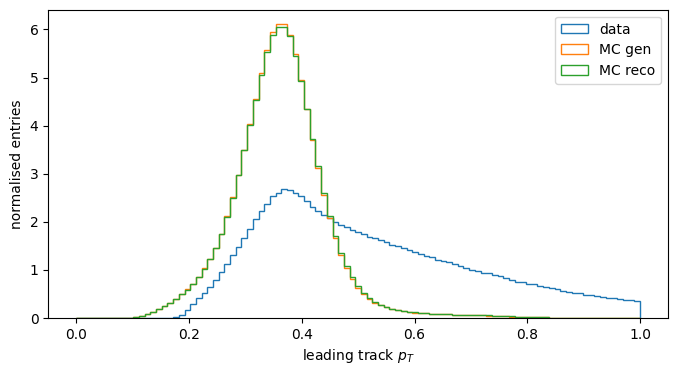

In [17]:
plt.figure(figsize=(8,4))
plt.hist(data["fLeadingTrackPt"], bins=np.linspace(0,1,100), label='data', density=True, color='tab:blue', histtype='step')
plt.hist(mc_reso["fLeadingGenPt"], bins=np.linspace(0,1,100), label='MC gen', density=True, color='tab:orange', histtype='step')
plt.hist(mc_reso["fLeadingRecoPt"], bins=np.linspace(0,1,100), label='MC reco', density=True, color='tab:green', histtype='step')
plt.xlabel("leading track $p_T$")
plt.ylabel("normalised entries")
plt.legend()
plt.show()


/var/folders/gv/cryfyln13nd7119gmmf2hywh0000gn/T/ipykernel_94311/3321505569.py:16: RuntimeWarning: invalid value encountered in divide
  ax2.plot(bin_centers, data_hist / mc_gen_hist, label='data/MC gen', color='tab:blue')
/var/folders/gv/cryfyln13nd7119gmmf2hywh0000gn/T/ipykernel_94311/3321505569.py:17: RuntimeWarning: invalid value encountered in divide
  ax2.plot(bin_centers, mc_reco_hist / mc_gen_hist, label='MC reco/MC gen', color='tab:green')


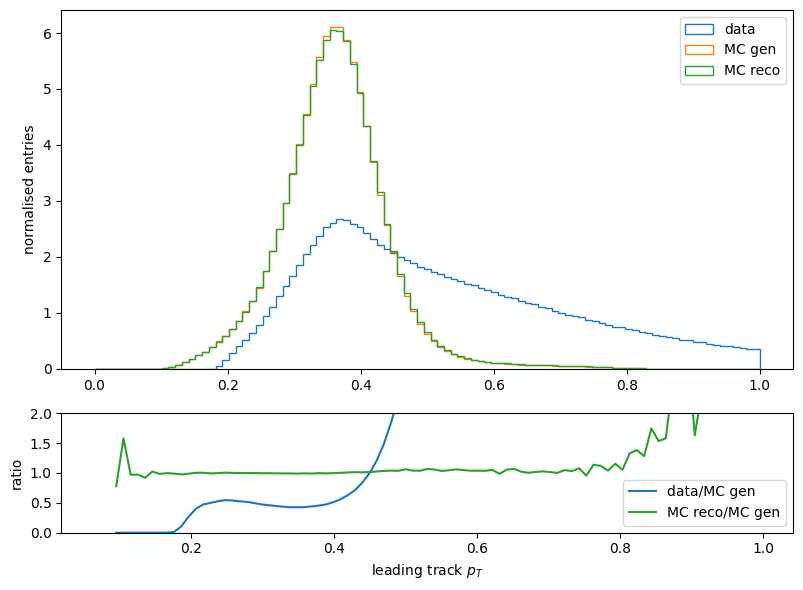

In [18]:
# make a plot with two subfigures, one for the distributions and then a ratio plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={"height_ratios": [3, 1]})
# plot the distributions
ax1.hist(data["fLeadingTrackPt"], bins=np.linspace(0,1,100), label='data', density=True, color='tab:blue', histtype='step')
ax1.hist(mc_reso["fLeadingGenPt"], bins=np.linspace(0,1,100), label='MC gen', density=True, color='tab:orange', histtype='step')
ax1.hist(mc_reso["fLeadingRecoPt"], bins=np.linspace(0,1,100), label='MC reco', density=True, color='tab:green', histtype='step')
# ax1.set_xlabel("leading track $p_T$")
ax1.set_ylabel("normalised entries")
ax1.legend()
# plot the ratio sharing the x axis and the same bins
bins = np.linspace(0,1,100)
data_hist, _ = np.histogram(data["fLeadingTrackPt"], bins=bins, density=True)
mc_gen_hist, _ = np.histogram(mc_reso["fLeadingGenPt"], bins=bins, density=True)
mc_reco_hist, _ = np.histogram(mc_reso["fLeadingRecoPt"], bins=bins, density=True)
bin_centers = (bins[:-1] + bins[1:]) / 2
ax2.plot(bin_centers, data_hist / mc_gen_hist, label='data/MC gen', color='tab:blue')
ax2.plot(bin_centers, mc_reco_hist / mc_gen_hist, label='MC reco/MC gen', color='tab:green')
ax2.set_xlabel("leading track $p_T$")
ax2.set_ylabel("ratio")
ax2.legend()
ax2.set_ylim(0, 2) # set y limits for better visibility of the ratio
plt.tight_layout()
plt.show()

In [19]:
ndim = 1 #The number of features present in your dataset
reco_model = of.MLP(ndim)
gen_model = of.MLP(ndim)
print(reco_model.summary(), gen_model.summary())

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,769 (65.50 KB)

 Trainable params: 16,769 (65.50 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,769 (65.50 KB)

 Trainable params: 16,769 (65.50 KB)

 Non-trainable params: 0 (0.00 B)

None None


In [23]:
omnifold = of.MultiFold(
    "test",
    reco_model,
    gen_model,
    data_data,
    mc_data,
    batch_size = 512,
    niter = 5,  #Number of Iterations                                                                                                                                                                                                  
    epochs=10,     
    weights_folder = 'weights',
    verbose = True,
    lr = 5e-5,
)

8811 training steps at reco and 7043 steps at gen


In [24]:
omnifold.Unfold()

ITERATION: 1
RUNNING STEP 1
Creating cached data from step 1
################################################################################
Train events used: 4511232, Test events used: 902246
################################################################################
Epoch 1/10
7048/7048 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.2373 - val_loss: 0.2301 - learning_rate: 5.0000e-05
Epoch 2/10
7048/7048 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.2296 - val_loss: 0.2291 - learning_rate: 5.0000e-05
Epoch 3/10
7048/7048 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.2285 - val_loss: 0.2284 - learning_rate: 5.0000e-05
Epoch 4/10
7048/7048 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - loss: 0.2275 - val_loss: 0.2272 - learning_rate: 5.0000e-05
Epoch 5/10
7048/7048 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 0.2266 - val_loss: 0.2267 - learning_rate: 5.0000e-05
Epoch 6/10
7048/7048 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.2263 - val_loss: 0.2265 - learning_rate: 5.0000e-05
Epoch 7/10
7048/7048 ━

In [27]:
unfolded = omnifold.weights_push

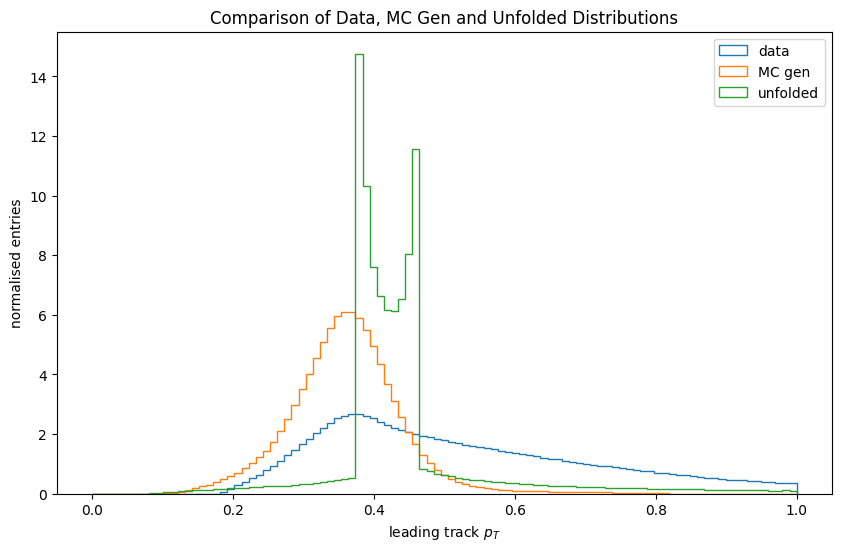

In [28]:
# plot the unfolded distribution together with the data and MC gen distribution
plt.figure(figsize=(10,6))
plt.hist(data["fLeadingTrackPt"], bins=np.linspace(0,1,100), label='data', density=True, color='tab:blue', histtype='step')
plt.hist(mc_reso["fLeadingGenPt"], bins=np.linspace(0,1,100), label='MC gen', density=True, color='tab:orange', histtype='step')
plt.hist(unfolded, bins=np.linspace(0,1,100), label='unfolded', density=True, color='tab:green', histtype='step')
plt.xlabel("leading track $p_T$")
plt.ylabel("normalised entries")
plt.title('Comparison of Data, MC Gen and Unfolded Distributions')
plt.legend()
plt.show()